In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
import gzip
import warnings
warnings.filterwarnings('ignore')

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                           f1_score, roc_auc_score, confusion_matrix,
                           roc_curve, classification_report)

# Handle imbalanced data
from imblearn.over_sampling import SMOTE

# Settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)

In [3]:
data = {}
files_to_load = {
    'patients': 'patients.csv.gz',
    'admissions': 'admissions.csv.gz',
    'icustays': 'icustays.csv.gz',
    'diagnoses': 'diagnoses_icd.csv.gz',
    'd_icd': 'd_icd_diagnoses.csv.gz'
}

for key, filename in files_to_load.items():
    print(f"\nUploading {filename}...")
    uploaded = files.upload()
    uploaded_filename = list(uploaded.keys())[0]

    with gzip.open(uploaded_filename, 'rb') as f:
        data[key] = pd.read_csv(f)

    print(f"Loaded {filename}: {len(data[key])} rows")

# Extract dataframes
patients = data['patients']
admissions = data['admissions']
icustays = data['icustays']
diagnoses = data['diagnoses']
d_icd = data['d_icd']


Uploading patients.csv.gz...


Saving patients.csv.gz to patients.csv (1).gz
Loaded patients.csv.gz: 100 rows

Uploading admissions.csv.gz...


Saving admissions.csv.gz to admissions.csv.gz
Loaded admissions.csv.gz: 275 rows

Uploading icustays.csv.gz...


Saving icustays.csv.gz to icustays.csv.gz
Loaded icustays.csv.gz: 140 rows

Uploading diagnoses_icd.csv.gz...


Saving diagnoses_icd.csv.gz to diagnoses_icd.csv.gz
Loaded diagnoses_icd.csv.gz: 4506 rows

Uploading d_icd_diagnoses.csv.gz...


Saving d_icd_diagnoses.csv.gz to d_icd_diagnoses.csv.gz
Loaded d_icd_diagnoses.csv.gz: 109775 rows


In [4]:
# Merge ICU stays with admissions to get mortality data
icu_cohort = pd.merge(
    icustays[['subject_id', 'hadm_id', 'stay_id', 'first_careunit', 'los']],
    admissions[['subject_id', 'hadm_id', 'admission_type', 'hospital_expire_flag']],
    on=['subject_id', 'hadm_id'],
    how='inner'
)

# Merge with patients to get demographics
icu_cohort = pd.merge(
    icu_cohort,
    patients[['subject_id', 'gender', 'anchor_age']],
    on='subject_id',
    how='inner'
)

# Filter adults (age >= 18)
icu_cohort = icu_cohort[icu_cohort['anchor_age'] >= 18].copy()

# Define outcome (ICU mortality = hospital mortality for ICU patients)
icu_cohort['icu_mortality'] = icu_cohort['hospital_expire_flag']

print(f"Final ICU cohort: {len(icu_cohort)} ICU stays")
print(f"Unique patients: {icu_cohort['subject_id'].nunique()}")
print(f"ICU mortality rate: {icu_cohort['icu_mortality'].mean():.2%}")
print(f"\nICU unit distribution:")
print(icu_cohort['first_careunit'].value_counts())

Final ICU cohort: 140 ICU stays
Unique patients: 100
ICU mortality rate: 14.29%

ICU unit distribution:
first_careunit
Surgical Intensive Care Unit (SICU)                 29
Medical Intensive Care Unit (MICU)                  29
Cardiac Vascular Intensive Care Unit (CVICU)        25
Medical/Surgical Intensive Care Unit (MICU/SICU)    23
Trauma SICU (TSICU)                                 16
Coronary Care Unit (CCU)                            13
Neuro Surgical Intensive Care Unit (Neuro SICU)      3
Neuro Stepdown                                       1
Neuro Intermediate                                   1
Name: count, dtype: int64


In [5]:
# Get diagnoses for ICU admissions
icu_diagnoses = pd.merge(
    icu_cohort[['subject_id', 'hadm_id']],
    diagnoses,
    on=['subject_id', 'hadm_id'],
    how='left'
)

# Count diagnoses per ICU admission
diag_counts = icu_diagnoses.groupby('hadm_id').size().reset_index(name='num_diagnoses')
icu_cohort = pd.merge(icu_cohort, diag_counts, on='hadm_id', how='left')
icu_cohort['num_diagnoses'] = icu_cohort['num_diagnoses'].fillna(0)

print(f"Average diagnoses per ICU admission: {icu_cohort['num_diagnoses'].mean():.1f}")
print(f"Range: {icu_cohort['num_diagnoses'].min()} to {icu_cohort['num_diagnoses'].max()}")

Average diagnoses per ICU admission: 24.8
Range: 3 to 96


In [6]:
# Define common high-risk conditions (based on ICD-10 code prefixes)
comorbidities = {
    'hypertension': ['I10', 'I11', 'I12', 'I13', 'I15'],
    'diabetes': ['E10', 'E11', 'E12', 'E13', 'E14'],
    'heart_failure': ['I50', 'I11.0', 'I13.0', 'I13.2'],
    'copd': ['J40', 'J41', 'J42', 'J43', 'J44'],
    'renal_failure': ['N17', 'N18', 'N19', 'I12.0', 'I13.1'],
    'liver_disease': ['K70', 'K71', 'K72', 'K73', 'K74', 'K76'],
    'cancer': ['C00', 'C01', 'C02', 'C03', 'C04', 'C05', 'C06', 'C07', 'C08', 'C09', 'C10',
               'C11', 'C12', 'C13', 'C14', 'C15', 'C16', 'C17', 'C18', 'C19', 'C20', 'C21',
               'C22', 'C23', 'C24', 'C25', 'C26', 'C30', 'C31', 'C32', 'C33', 'C34'],
    'sepsis': ['A40', 'A41', 'R65.2'],
    'pneumonia': ['J12', 'J13', 'J14', 'J15', 'J16', 'J17', 'J18'],
    'mi': ['I21', 'I22', 'I25.2']  # myocardial infarction
}

# Function to check if a patient has a condition based on ICD code
def has_condition(hadm_id, condition_codes):
    patient_dxs = icu_diagnoses[icu_diagnoses['hadm_id'] == hadm_id]['icd_code'].astype(str).tolist()
    if not patient_dxs:
        return 0
    for dx in patient_dxs:
        for code in condition_codes:
            if dx.startswith(code):
                return 1
    return 0

# Create feature dataframe with demographics and diagnoses
feature_df = icu_cohort[['stay_id', 'hadm_id', 'subject_id', 'anchor_age', 'gender',
                         'first_careunit', 'los', 'icu_mortality', 'num_diagnoses']].copy()

# Add comorbidity flags
print("\nComorbidity prevalence in ICU patients:")
for condition, codes in comorbidities.items():
    feature_df[f'has_{condition}'] = feature_df['hadm_id'].apply(
        lambda x: has_condition(x, codes)
    )
    prevalence = feature_df[f'has_{condition}'].mean()
    print(f"  {condition}: {prevalence:.1%}")

# Create total comorbidity count
comorbidity_cols = [f'has_{c}' for c in comorbidities.keys()]
feature_df['comorbidity_count'] = feature_df[comorbidity_cols].sum(axis=1)

print(f"\nAverage number of comorbidities per patient: {feature_df['comorbidity_count'].mean():.1f}")
print(f"Patients with 0 comorbidities: {(feature_df['comorbidity_count'] == 0).mean():.1%}")


Comorbidity prevalence in ICU patients:
  hypertension: 25.7%
  diabetes: 17.9%
  heart_failure: 15.0%
  copd: 10.7%
  renal_failure: 21.4%
  liver_disease: 5.7%
  cancer: 2.1%
  sepsis: 7.1%
  pneumonia: 5.0%
  mi: 5.7%

Average number of comorbidities per patient: 1.2
Patients with 0 comorbidities: 65.7%


In [9]:
print("DEMOGRAPHICS & DIAGNOSES ANALYSIS")

# Age analysis
print(f"\nAge Statistics:")
print(f"   Survivors - Mean age: {feature_df[feature_df['icu_mortality']==0]['anchor_age'].mean():.1f} years")
print(f"   Non-survivors - Mean age: {feature_df[feature_df['icu_mortality']==1]['anchor_age'].mean():.1f} years")

# Gender analysis
print(f"\nGender Analysis:")
mortality_by_gender = feature_df.groupby('gender')['icu_mortality'].mean()
print(f"   Male mortality rate: {mortality_by_gender.get('M', 0):.2%}")
print(f"   Female mortality rate: {mortality_by_gender.get('F', 0):.2%}")

# Diagnosis count analysis
print(f"\nDiagnosis Count:")
print(f"   Survivors - Avg diagnoses: {feature_df[feature_df['icu_mortality']==0]['num_diagnoses'].mean():.1f}")
print(f"   Non-survivors - Avg diagnoses: {feature_df[feature_df['icu_mortality']==1]['num_diagnoses'].mean():.1f}")

# Comorbidity analysis
print(f"\nComorbidity Count:")
print(f"   Survivors - Avg comorbidities: {feature_df[feature_df['icu_mortality']==0]['comorbidity_count'].mean():.1f}")
print(f"   Non-survivors - Avg comorbidities: {feature_df[feature_df['icu_mortality']==1]['comorbidity_count'].mean():.1f}")

# Mortality by specific conditions
print(f"\nMortality Rate by Condition:")
for condition in comorbidities.keys():
    with_condition = feature_df[feature_df[f'has_{condition}']==1]['icu_mortality'].mean()
    without_condition = feature_df[feature_df[f'has_{condition}']==0]['icu_mortality'].mean()
    if with_condition > without_condition * 1.2:  # Show if >20% higher
        print(f"   {condition}: {with_condition:.2%} vs {without_condition:.2%} (without)")

DEMOGRAPHICS & DIAGNOSES ANALYSIS

Age Statistics:
   Survivors - Mean age: 60.8 years
   Non-survivors - Mean age: 69.3 years

Gender Analysis:
   Male mortality rate: 20.78%
   Female mortality rate: 6.35%

Diagnosis Count:
   Survivors - Avg diagnoses: 22.4
   Non-survivors - Avg diagnoses: 39.4

Comorbidity Count:
   Survivors - Avg comorbidities: 1.0
   Non-survivors - Avg comorbidities: 2.2

Mortality Rate by Condition:
   hypertension: 25.00% vs 10.58% (without)
   heart_failure: 33.33% vs 10.92% (without)
   copd: 20.00% vs 13.60% (without)
   renal_failure: 30.00% vs 10.00% (without)
   cancer: 66.67% vs 13.14% (without)
   sepsis: 50.00% vs 11.54% (without)
   pneumonia: 28.57% vs 13.53% (without)
   mi: 25.00% vs 13.64% (without)


VISUALIZATIONS


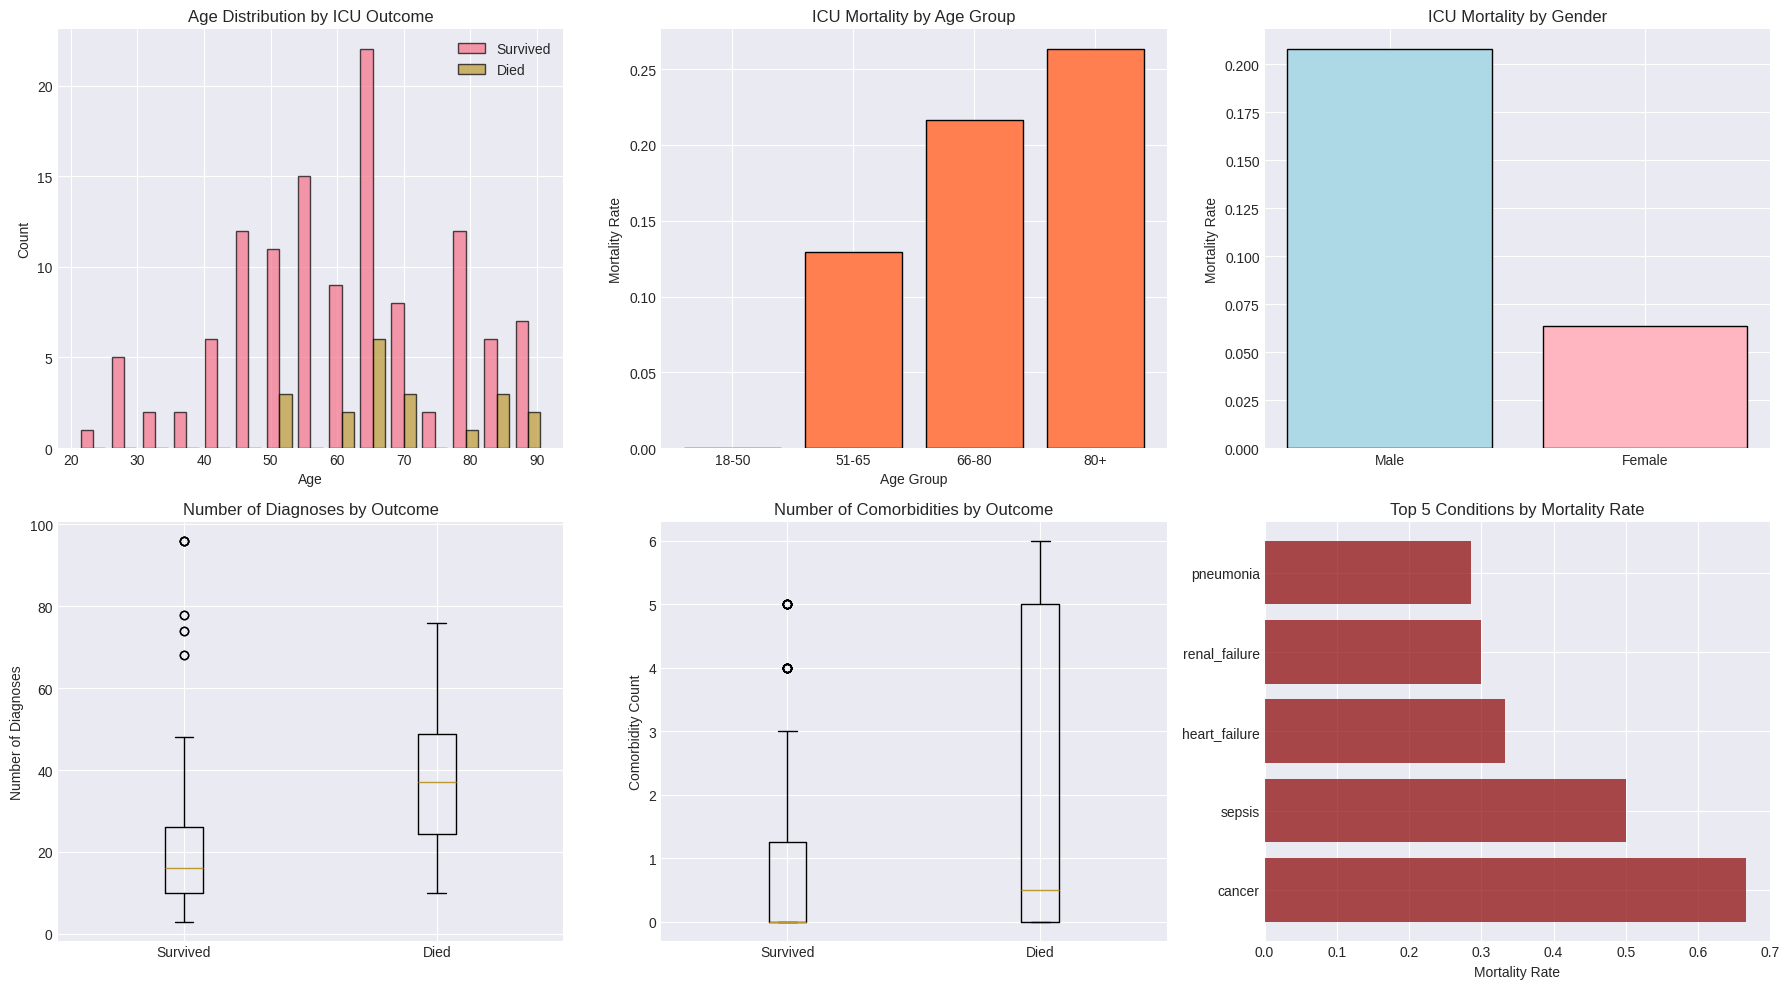

In [11]:
print("VISUALIZATIONS")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Age distribution by outcome
axes[0,0].hist([feature_df[feature_df['icu_mortality']==0]['anchor_age'],
                feature_df[feature_df['icu_mortality']==1]['anchor_age']],
               bins=15, label=['Survived', 'Died'], alpha=0.7, edgecolor='black')
axes[0,0].set_title('Age Distribution by ICU Outcome')
axes[0,0].set_xlabel('Age')
axes[0,0].set_ylabel('Count')
axes[0,0].legend()

# 2. Mortality by age group
feature_df['age_group'] = pd.cut(feature_df['anchor_age'], bins=[18, 50, 65, 80, 100],
                                  labels=['18-50', '51-65', '66-80', '80+'])
age_group_mortality = feature_df.groupby('age_group')['icu_mortality'].mean()
axes[0,1].bar(age_group_mortality.index, age_group_mortality.values, color='coral', edgecolor='black')
axes[0,1].set_title('ICU Mortality by Age Group')
axes[0,1].set_xlabel('Age Group')
axes[0,1].set_ylabel('Mortality Rate')

# 3. Mortality by gender
axes[0,2].bar(['Male', 'Female'],
              [mortality_by_gender.get('M', 0), mortality_by_gender.get('F', 0)],
              color=['lightblue', 'lightpink'], edgecolor='black')
axes[0,2].set_title('ICU Mortality by Gender')
axes[0,2].set_ylabel('Mortality Rate')

# 4. Diagnosis count by outcome
axes[1,0].boxplot([feature_df[feature_df['icu_mortality']==0]['num_diagnoses'],
                   feature_df[feature_df['icu_mortality']==1]['num_diagnoses']],
                  labels=['Survived', 'Died'])
axes[1,0].set_title('Number of Diagnoses by Outcome')
axes[1,0].set_ylabel('Number of Diagnoses')

# 5. Comorbidity count by outcome
axes[1,1].boxplot([feature_df[feature_df['icu_mortality']==0]['comorbidity_count'],
                   feature_df[feature_df['icu_mortality']==1]['comorbidity_count']],
                  labels=['Survived', 'Died'])
axes[1,1].set_title('Number of Comorbidities by Outcome')
axes[1,1].set_ylabel('Comorbidity Count')

# 6. Top conditions by mortality impact
condition_mortality = {cond: feature_df[feature_df[f'has_{cond}']==1]['icu_mortality'].mean()
                       for cond in comorbidities.keys()}
top_conditions = pd.Series(condition_mortality).sort_values(ascending=False).head(5)
axes[1,2].barh(top_conditions.index, top_conditions.values, color='darkred', alpha=0.7)
axes[1,2].set_title('Top 5 Conditions by Mortality Rate')
axes[1,2].set_xlabel('Mortality Rate')

plt.tight_layout()
plt.show()

In [14]:
print("PREPARING DATA FOR MACHINE LEARNING")

# Create feature matrix (demographics + diagnosis-based features only)
X = pd.DataFrame()
X['age'] = feature_df['anchor_age']
X['gender_male'] = (feature_df['gender'] == 'M').astype(int)
X['num_diagnoses'] = feature_df['num_diagnoses']
X['comorbidity_count'] = feature_df['comorbidity_count']

# Add individual comorbidity flags
for condition in comorbidities.keys():
    X[f'has_{condition}'] = feature_df[f'has_{condition}']

# Target variable
y = feature_df['icu_mortality']

print(f"Feature matrix shape: {X.shape}")
print(f"   Features: {list(X.columns)}")
print(f"\n   Target distribution:")
print(y.value_counts())
print(f"   Class imbalance ratio: {y.value_counts()[0]/y.value_counts()[1]:.1f}:1")

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"\n   Train set: {X_train.shape[0]} ICU stays")
print(f"   Test set: {X_test.shape[0]} ICU stays")

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Apply SMOTE to handle class imbalance
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print(f"\nAfter SMOTE balancing:")
print(f"   Train set: {X_train_resampled.shape[0]} samples")
print(f"   Balanced classes: {pd.Series(y_train_resampled).value_counts().to_dict()}")

PREPARING DATA FOR MACHINE LEARNING
Feature matrix shape: (140, 14)
   Features: ['age', 'gender_male', 'num_diagnoses', 'comorbidity_count', 'has_hypertension', 'has_diabetes', 'has_heart_failure', 'has_copd', 'has_renal_failure', 'has_liver_disease', 'has_cancer', 'has_sepsis', 'has_pneumonia', 'has_mi']

   Target distribution:
icu_mortality
0    120
1     20
Name: count, dtype: int64
   Class imbalance ratio: 6.0:1

   Train set: 98 ICU stays
   Test set: 42 ICU stays

After SMOTE balancing:
   Train set: 168 samples
   Balanced classes: {1: 84, 0: 84}


In [16]:
print("MODEL TRAINING")

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")

    # Train
    model.fit(X_train_resampled, y_train_resampled)

    # Predict
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    # Calculate metrics
    results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1': f1_score(y_test, y_pred, zero_division=0),
        'AUC': roc_auc_score(y_test, y_prob),
        'Model': model
    }

    print(f"   Accuracy:  {results[name]['Accuracy']:.3f}")
    print(f"   Precision: {results[name]['Precision']:.3f}")
    print(f"   Recall:    {results[name]['Recall']:.3f}")
    print(f"   F1-Score:  {results[name]['F1']:.3f}")
    print(f"   AUC-ROC:   {results[name]['AUC']:.3f}")

MODEL TRAINING

Training Logistic Regression...
   Accuracy:  0.738
   Precision: 0.273
   Recall:    0.500
   F1-Score:  0.353
   AUC-ROC:   0.755

Training Random Forest...
   Accuracy:  0.810
   Precision: 0.333
   Recall:    0.333
   F1-Score:  0.333
   AUC-ROC:   0.699


MODEL COMPARISON

Model Performance Comparison:
                     Accuracy Precision    Recall        F1       AUC
Logistic Regression  0.738095  0.272727       0.5  0.352941   0.75463
Random Forest        0.809524  0.333333  0.333333  0.333333  0.699074

Best model for ICU mortality: Logistic Regression (AUC = 0.755)


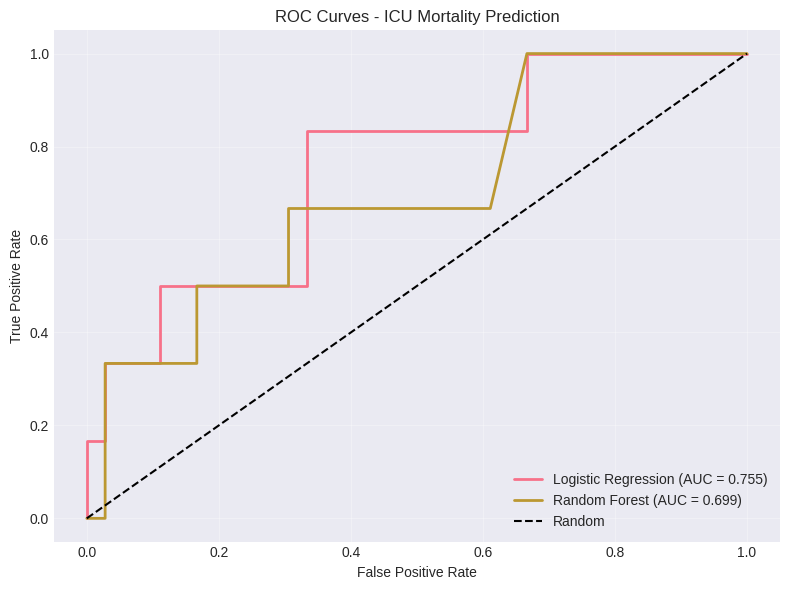

In [17]:
print("MODEL COMPARISON")

# Comparison dataframe
comparison = pd.DataFrame(results).T[['Accuracy', 'Precision', 'Recall', 'F1', 'AUC']]
print("\nModel Performance Comparison:")
print(comparison.round(3))

# Find best model by AUC
best_model_name = comparison['AUC'].idxmax()
best_model = results[best_model_name]['Model']
print(f"\nBest model for ICU mortality: {best_model_name} (AUC = {comparison.loc[best_model_name, 'AUC']:.3f})")

# Plot ROC curves
plt.figure(figsize=(8, 6))
for name in results:
    y_prob = results[name]['Model'].predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {results[name]['AUC']:.3f})", linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - ICU Mortality Prediction')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

FEATURE IMPORTANCE ANALYSIS


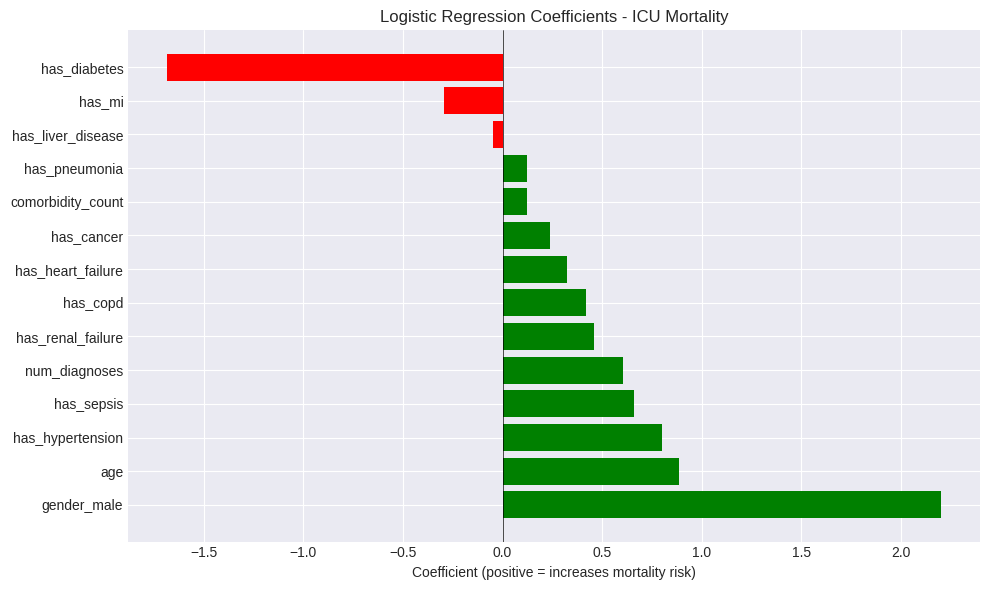


Factors that INCREASE ICU mortality risk:
          Feature  Coefficient
      gender_male     2.202608
              age     0.886834
 has_hypertension     0.799010
       has_sepsis     0.662495
    num_diagnoses     0.604120
has_renal_failure     0.459662
         has_copd     0.420834
has_heart_failure     0.326151

Factors that DECREASE ICU mortality risk:
          Feature  Coefficient
         has_copd     0.420834
has_heart_failure     0.326151
       has_cancer     0.235927
comorbidity_count     0.123771
    has_pneumonia     0.122711
has_liver_disease    -0.045782
           has_mi    -0.293404
     has_diabetes    -1.684557


In [18]:
print("FEATURE IMPORTANCE ANALYSIS")

if best_model_name == 'Random Forest':
    # Feature importance from Random Forest
    importance = pd.DataFrame({
        'Feature': X.columns,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False)

    # Plot
    plt.figure(figsize=(10, 6))
    plt.barh(importance['Feature'][:10], importance['Importance'][:10])
    plt.xlabel('Importance')
    plt.title(f'Top 10 Features for ICU Mortality - {best_model_name}')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

    print("\nTop 10 Most Important Features:")
    print(importance.head(10).to_string(index=False))

elif best_model_name == 'Logistic Regression':
    # Coefficients from Logistic Regression
    coefficients = pd.DataFrame({
        'Feature': X.columns,
        'Coefficient': best_model.coef_[0]
    }).sort_values('Coefficient', ascending=False)

    # Plot
    plt.figure(figsize=(10, 6))
    top_coef = pd.concat([coefficients.head(8), coefficients.tail(8)])
    colors = ['green' if c > 0 else 'red' for c in top_coef['Coefficient']]
    plt.barh(top_coef['Feature'], top_coef['Coefficient'], color=colors)
    plt.xlabel('Coefficient (positive = increases mortality risk)')
    plt.title('Logistic Regression Coefficients - ICU Mortality')
    plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
    plt.tight_layout()
    plt.show()

    print("\nFactors that INCREASE ICU mortality risk:")
    print(coefficients.head(8).to_string(index=False))
    print("\nFactors that DECREASE ICU mortality risk:")
    print(coefficients.tail(8).to_string(index=False))

CONFUSION MATRIX FOR BEST MODEL


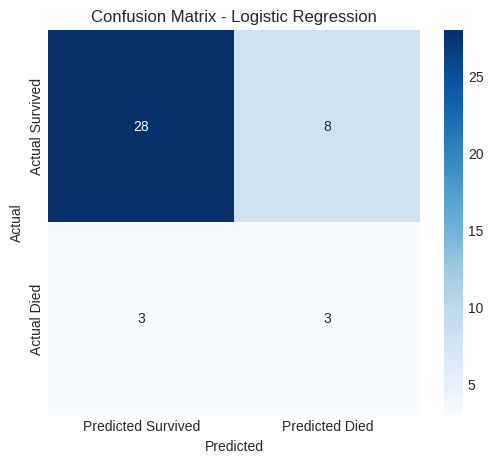


Confusion Matrix Analysis:
   True Negatives (correctly predicted survival): 28
   False Positives (predicted death, actual survival): 8
   False Negatives (predicted survival, actual death): 3
   True Positives (correctly predicted death): 3

   Sensitivity (Recall): 0.500 - Ability to identify patients who will die
   Specificity: 0.778 - Ability to identify patients who will survive


In [19]:
print("CONFUSION MATRIX FOR BEST MODEL")

y_pred_best = results[best_model_name]['Model'].predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Survived', 'Predicted Died'],
            yticklabels=['Actual Survived', 'Actual Died'])
plt.title(f'Confusion Matrix - {best_model_name}')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Calculate metrics from confusion matrix
tn, fp, fn, tp = cm.ravel()
print(f"\nConfusion Matrix Analysis:")
print(f"   True Negatives (correctly predicted survival): {tn}")
print(f"   False Positives (predicted death, actual survival): {fp}")
print(f"   False Negatives (predicted survival, actual death): {fn}")
print(f"   True Positives (correctly predicted death): {tp}")
print(f"\n   Sensitivity (Recall): {tp/(tp+fn):.3f} - Ability to identify patients who will die")
print(f"   Specificity: {tn/(tn+fp):.3f} - Ability to identify patients who will survive")

In [21]:
print("CLINICAL SUMMARY: ICU MORTALITY PREDICTION")

print(f"""
 Cohort Characteristics:**
   - Total ICU stays: {len(feature_df)}
   - ICU mortality rate: {y.mean():.2%}
   - Average age: {feature_df['anchor_age'].mean():.1f} years
   - Average diagnoses per patient: {feature_df['num_diagnoses'].mean():.1f}
   - Average comorbidities: {feature_df['comorbidity_count'].mean():.1f}

 Model Performance (using only demographics & diagnoses):**
   - Best model: {best_model_name}
   - AUC-ROC: {comparison.loc[best_model_name, 'AUC']:.3f}
   - Accuracy: {comparison.loc[best_model_name, 'Accuracy']:.3f}
   - Sensitivity: {comparison.loc[best_model_name, 'Recall']:.3f}
   - Specificity: {tn/(tn+fp):.3f}

 Top Risk Factors Identified:"""
)

# Show top features from importance analysis
if best_model_name == 'Random Forest':
    top_features = importance.head(5)
    for i, row in top_features.iterrows():
        print(f"   {i+1}. {row['Feature']} (importance: {row['Importance']:.3f})")
else:
    top_features = coefficients.head(5)
    for i, row in top_features.iterrows():
        print(f"   {i+1}. {row['Feature']} (coefficient: {row['Coefficient']:.3f})")

print(f"""
 Clinical Interpretation:**

   Age is a strong predictor of ICU mortality - older patients have significantly higher risk.

   Comorbidity burden matters - each additional chronic condition increases mortality risk.

   Specific high-risk conditions identified:
""")

# Show conditions with highest mortality impact
condition_impact = {}
for condition in comorbidities.keys():
    with_cond = feature_df[feature_df[f'has_{condition}']==1]['icu_mortality'].mean()
    without_cond = feature_df[feature_df[f'has_{condition}']==0]['icu_mortality'].mean()
    if with_cond > without_cond * 1.3:  # 30% higher
        condition_impact[condition] = with_cond / without_cond

for condition, impact in sorted(condition_impact.items(), key=lambda x: x[1], reverse=True)[:3]:
    print(f"   • {condition.replace('_', ' ').title()}: {impact:.1f}x higher mortality risk")

print(f"""
 Important Limitations:**
   - This analysis uses MIMIC-IV Demo data (100 patients, {len(feature_df)} ICU stays)
   - Results are for educational purposes, not clinical use
   - Missing important predictors (vitals, labs, treatments)
   - Small sample size limits statistical power

 Next Steps with Full MIMIC-IV:**
   - Add vital signs from chartevents
   - Include lab results from labevents
   - Add medications and procedures
   - Use temporal models for time-series data
""")

CLINICAL SUMMARY: ICU MORTALITY PREDICTION

 Cohort Characteristics:**
   - Total ICU stays: 140
   - ICU mortality rate: 14.29%
   - Average age: 62.0 years
   - Average diagnoses per patient: 24.8
   - Average comorbidities: 1.2

 Model Performance (using only demographics & diagnoses):**
   - Best model: Logistic Regression
   - AUC-ROC: 0.755
   - Accuracy: 0.738
   - Sensitivity: 0.500
   - Specificity: 0.778

 Top Risk Factors Identified:
   2. gender_male (coefficient: 2.203)
   1. age (coefficient: 0.887)
   5. has_hypertension (coefficient: 0.799)
   12. has_sepsis (coefficient: 0.662)
   3. num_diagnoses (coefficient: 0.604)

 Clinical Interpretation:**

   Age is a strong predictor of ICU mortality - older patients have significantly higher risk.

   Comorbidity burden matters - each additional chronic condition increases mortality risk.

   Specific high-risk conditions identified:

   • Cancer: 5.1x higher mortality risk
   • Sepsis: 4.3x higher mortality risk
   • Heart F